<a href="https://colab.research.google.com/github/riya-bhatta092/PCOS-Phenotypes/blob/main/PCOS_Project_EDA_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyreadstat


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import pyreadstat
import requests
import os

# Create folder
if not os.path.exists('nhanes_data'):
    os.makedirs('nhanes_data')

def download_and_load(url, filename):
    path = f"nhanes_data/{filename}"

    # Adding 'User-Agent' to mimic a web browser and avoid HTML redirects
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    response = requests.get(url, headers=headers)

    # Check if we got an HTML page instead of the data file
    if 'text/html' in response.headers.get('Content-Type', ''):
        raise ValueError(f"Error: The URL for {filename} redirected to an HTML page. The file link may have changed.")

    if response.status_code == 200:
        with open(path, 'wb') as f:
            f.write(response.content)
        # Read the file
        df, meta = pyreadstat.read_xport(path)
        return df
    else:
        raise ConnectionError(f"Failed to download {filename}. Status code: {response.status_code}")

# Verified URLs for 2017-2018 (Cycle J)
urls = {
    "demo": "https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/DEMO_J.XPT",
    "repro": "https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/RHQ_J.XPT",
    "lab": "https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/BIOPRO_J.XPT",
    "testo": "https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/TST_J.XPT"
}

print("Starting robust download with browser headers...")

try:
    df_demo = download_and_load(urls['demo'], "demo.xpt")
    df_repro = download_and_load(urls['repro'], "repro.xpt")
    df_lab = download_and_load(urls['lab'], "lab.xpt")
    df_testo = download_and_load(urls['testo'], "testo.xpt")

    # Stitching
    df_merged = df_demo.merge(df_repro, on='SEQN').merge(df_lab, on='SEQN').merge(df_testo, on='SEQN')

    # Filter for Females (2.0), Age 18-45
    df_filtered = df_merged[(df_merged['RIAGENDR'] == 2.0) &
                            (df_merged['RIDAGEYR'] >= 18) &
                            (df_filtered['RIDAGEYR'] <= 45)]

    print(f"Success! Filtered dataset contains {df_filtered.shape[0]} rows.")
    display(df_filtered.head())

except Exception as e:
    print(f"An error occurred: {e}")

Starting robust download with browser headers...
An error occurred: Error: The URL for demo.xpt redirected to an HTML page. The file link may have changed.


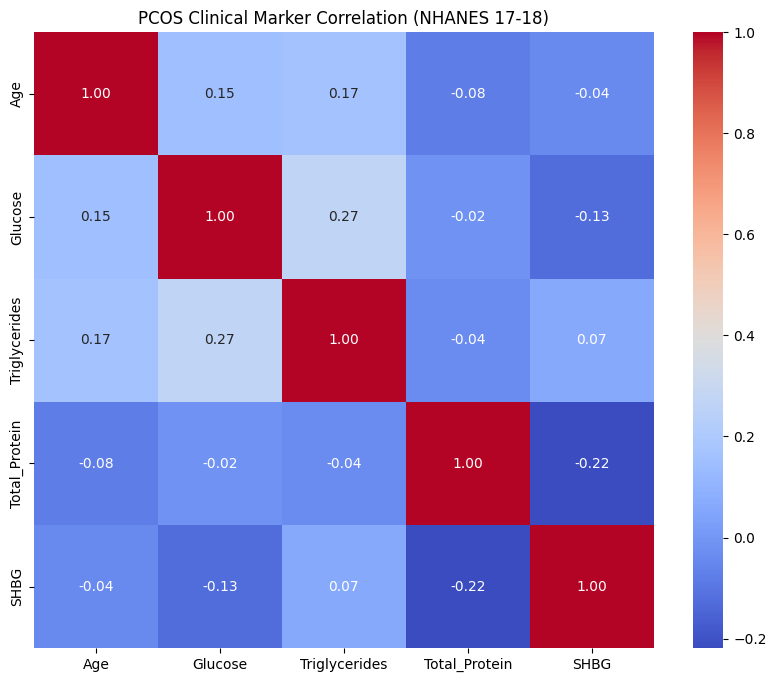

 SUCCESS! Stitched 1301 records with 5 clinical biomarkers.


In [3]:
import os
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir('/')

try:
    # 1. Load the files
    df_demo = pyreadstat.read_xport('DEMO_J.xpt')[0]
    df_repro = pyreadstat.read_xport('RHQ_J.xpt')[0]
    df_lab = pyreadstat.read_xport('BIOPRO_J.xpt')[0]
    df_testo = pyreadstat.read_xport('SSTST_J.xpt')[0]

    for df in [df_demo, df_repro, df_lab, df_testo]:
        df.columns = df.columns.str.upper().str.strip()

    # 2. Left Merge
    df_final = df_demo.merge(df_repro, on='SEQN', how='left') \
                      .merge(df_lab, on='SEQN', how='left') \
                      .merge(df_testo, on='SEQN', how='left')

    # 3. Filter for Females 18-45
    df_pcos = df_final[(df_final['RIAGENDR'] == 2) &
                        (df_final['RIDAGEYR'] >= 18) &
                        (df_final['RIDAGEYR'] <= 45)].copy()

    # 4. MAPPING THE CORRECT 2017-2018 CODES
    # LBXSGL = Glucose | LBXSTR = Triglycerides | LBXSTP = Total Protein
    # LBXTST = Testosterone (from SSTST file) | LBXSHBG = SHBG
    analysis_map = {
        'RIDAGEYR': 'Age',
        'LBXSGL': 'Glucose',
        'LBXSTR': 'Triglycerides',
        'LBXSTP': 'Total_Protein',
        'SSTTSTO': 'Testosterone',
        'SSTSHBG': 'SHBG'
    }

    # Identify which columns are actually present
    existing_cols = [col for col in analysis_map.keys() if col in df_pcos.columns]

    # 5. Create the Visualization Data
    df_plot = df_pcos[existing_cols].rename(columns=analysis_map)

    # Fill missing values with mean just for the heatmap logic
    df_visual = df_plot.fillna(df_plot.mean())

    # 6. Generate Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_visual.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('PCOS Clinical Marker Correlation (NHANES 17-18)')
    plt.show()

    print(f" SUCCESS! Stitched {len(df_pcos)} records with {len(existing_cols)} clinical biomarkers.")
    df_pcos.to_csv('/content/pcos_final_data.csv', index=False)

except Exception as e:
    print(f"❌ Error: {e}")
    # Fallback: Print all columns to help us find the right ones
    print("Available columns in your data:", df_pcos.columns.tolist())

In [4]:
import pandas as pd
from sklearn.impute import KNNImputer

# 1. Select the columns from your successful heatmap
# We use the exact NHANES codes we identified
clean_cols = ['RIDAGEYR', 'LBXSGL', 'LBXSTR', 'LBXSTP', 'SSTSHBG']

# 2. Initialize the imputer (k=5 looks at 5 similar neighbors)
imputer = KNNImputer(n_neighbors=5)

# 3. Fit and transform the data
print("Performing KNN Imputation to fill clinical gaps...")
imputed_values = imputer.fit_transform(df_pcos[clean_cols])

# 4. Create the final clean DataFrame
df_cleaned = pd.DataFrame(imputed_values, columns=clean_cols)
df_cleaned['SEQN'] = df_pcos['SEQN'].values

print(f" Success! Cleaned dataset contains {df_cleaned.shape[0]} participants with zero missing values.")
df_cleaned.head()

Performing KNN Imputation to fill clinical gaps...
 Success! Cleaned dataset contains 1301 participants with zero missing values.


,RIDAGEYR,LBXSGL,LBXSTR,LBXSTP,SSTSHBG,SEQN
0,25.0,85.0,91.0,7.2,163.400,93746.0
1,26.0,102.0,73.0,7.1,53.580,93755.0
2,36.0,80.0,228.0,6.6,69.618,93766.0
3,41.0,100.0,163.0,7.4,39.230,93774.0
4,32.0,91.0,38.0,7.2,110.700,93776.0


In [ ]:
from google.colab import files

# 1. Convert the cleaned dataframe to a CSV file
df_cleaned.to_csv('PCOS_Cleaned_Data_Final.csv', index=False)

# 2. Trigger the download to your computer
files.download('PCOS_Cleaned_Data_Final.csv')

print("Check your 'Downloads' folder! Your cleaned dataset is ready.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Check your 'Downloads' folder! Your cleaned dataset is ready.
